## Cohort analysis of randomly-generated dataset

In [44]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df_transactions = pd.read_csv('/home/gabriel/Documents/GitHub/random-cohort-rfm-analysis/data/transactions.csv')

# convert order_date to datetime
df_transactions['order_date'] = pd.to_datetime(df_transactions['order_date'])

# converting date of purchase to format 'year-month' so we can group by month of purchase
df_transactions['order_month'] = df_transactions['order_date'].dt.to_period('M')

In [39]:
# find the first purchase of each customer
cohort = df_transactions.groupby('customer_id')['order_date'].min()

# convert to year-month format
cohort = cohort.dt.to_period('M')

# generate cohort column in original dataframe
df_transactions['cohort'] = df_transactions['customer_id'].map(cohort)

# months passed since first purchase
cohort_index = df_transactions['order_month'].astype(int) - df_transactions['cohort'].astype(int)
df_transactions['cohort_index'] = cohort_index

In [40]:
# creating a retention table
cohort_table = (df_transactions.groupby(['cohort', 'cohort_index']).customer_id.nunique().unstack())

#calculating retention rate with rounding to 2 decimal places
retention = round(cohort_table.divide(cohort_table.iloc[:,0], axis=0),2)



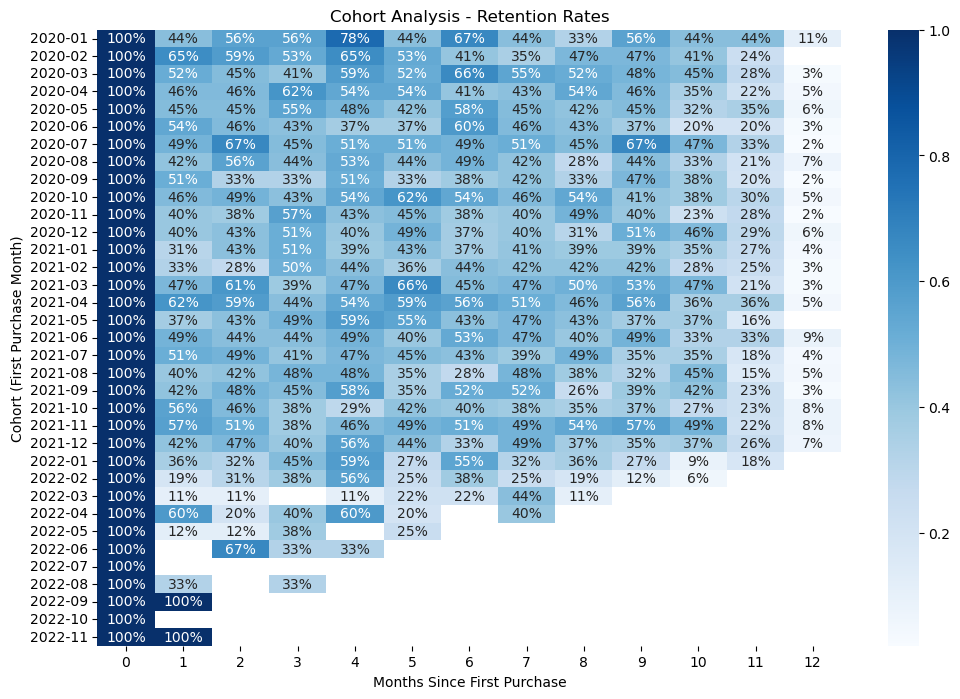

In [47]:
# visualizing retention table
plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title('Cohort Analysis - Retention Rates')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.yticks(rotation=0)
plt.show()